### Reduser example

In [2]:

from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    messages: Annotated[list[str], add]

In [4]:
def node1(state: State) -> State:
    return {"messages": ["message1"]}

def node2(state: State) -> State:
    return {"messages":["message2"]}

In [5]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(State)

graph.add_node("node1", node1)
graph.add_node("node2", node2)

graph.add_edge(START, 'node1')
graph.add_edge('node1', 'node2')
graph.add_edge('node1', END)

app = graph.compile()


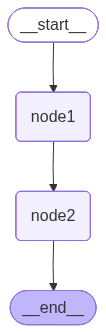

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result = app.invoke({'messages':['Bob']})
print(result)

{'messages': ['Bob', 'message1', 'message2']}


### Without annotation

In [8]:
from typing import Annotated
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[str]

In [9]:
def node1(state: State) -> State:
    return {"messages": ["message1"]}

def node2(state: State) -> State:
    return {"messages":["message2"]}

In [10]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(State)

graph.add_node("node1", node1)
graph.add_node("node2", node2)

graph.add_edge(START, 'node1')
graph.add_edge('node1', 'node2')
graph.add_edge('node1', END)

app = graph.compile()


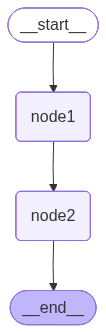

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({'messages':['Bob']})
print(result)

{'messages': ['message2']}
